# Object Detection with YOLOXTrainer

This notebook shows how to train an **YOLOX object detection** model on the **BCCD** (Blood Cell Count and Detection) dataset using Datamint's **Trainer API**.

## About YOLOX

YOLOX is an anchor-free, single-stage object detector that simplifies the YOLO pipeline by removing the need to pre-define anchor boxes. It comes in six size variants — `nano`, `tiny`, `s`, `m`, `l`, `x` — so you can trade speed for accuracy with a single parameter.

> Ge, Z., Liu, S., Wang, F., Li, Z., & Sun, J. (2021). YOLOX: Exceeding YOLO Series in 2021. *arXiv preprint arXiv:2107.08430.*

## What You'll Learn

1. Upload images and bounding box annotations to Datamint
2. Train a YOLOX detection model with **one line of code**
3. Visualize predictions locally
4. Deploy the trained model to the Datamint server and run remote inference

## Required Dependencies

```bash
# YOLOX — PyPI package is broken on Python 3.12.
# Fix: install from the git tag with --no-build-isolation so the build runs
# inside the current environment where torch already exists.

pip install "git+https://github.com/Megvii-BaseDetection/YOLOX.git@0.3.0" \
    --no-deps --no-build-isolation
pip install loguru thop pycocotools

# torchmetrics[detection] pulls in pycocotools (required by MeanAveragePrecision)
pip install datamint[dev] "torchmetrics[detection]>=1.0"
```

In [ ]:
from datamint import Api

PROJECT_NAME = "bccd_detection"
api = Api()

## 1. Setup: Create Project

In [2]:
proj = api.projects.create(
    name=PROJECT_NAME,
    description="Blood cell detection tutorial using YOLOX",
    exists_ok=True,
)
proj

bccd_detection
2026-06-15T11:51:23.211Z
luandalmazo@gmail.com
False
364
Blood cell detection tutorial using YOLOX


## 2. Dataset Preparation: Download and Upload BCCD

This section downloads the BCCD dataset and uploads it to Datamint.
If you already have the data inside Datamint, you can **skip to Section 3**.

In this section, we will:
- Download the BCCD dataset from GitHub
- Parse Pascal VOC XML annotations
- Upload microscopy images to Datamint
- Upload corresponding bounding box annotations

### 2.1 Download BCCD Dataset

> Shenggan. *BCCD Dataset*. GitHub, 2018. https://github.com/Shenggan/BCCD_Dataset (MIT License).

The dataset contains 364 microscopy images of blood cells with Pascal VOC bounding box annotations across three classes: `RBC` (red blood cells), `WBC` (white blood cells), and `Platelets`.

In [3]:
import zipfile
from pathlib import Path

DATA_DIR = Path("/tmp/bccd_dataset")
BCCD_URL = "https://github.com/Shenggan/BCCD_Dataset/archive/refs/heads/master.zip"

if not DATA_DIR.exists():
    print("Downloading BCCD dataset...")
    !wget -q -O /tmp/bccd.zip {BCCD_URL}
    with zipfile.ZipFile("/tmp/bccd.zip") as zf:
        zf.extractall(DATA_DIR)
    print("Done.")
else:
    print(f"Dataset already exists at {DATA_DIR}")

IMAGES_DIR = DATA_DIR / "BCCD_Dataset-master" / "BCCD" / "JPEGImages"
ANNOTS_DIR = DATA_DIR / "BCCD_Dataset-master" / "BCCD" / "Annotations"

image_files = sorted(IMAGES_DIR.glob("*.jpg"))
print(f"{len(image_files)} images found")

Done.
364 images found


### 2.2 Parse Annotations

In [4]:
import xml.etree.ElementTree as ET
from dataclasses import dataclass, field


@dataclass
class Box:
    label: str
    x1: float; y1: float; x2: float; y2: float


@dataclass
class Sample:
    image_path: Path
    boxes: list[Box] = field(default_factory=list)


def parse_voc_xml(xml_path: Path) -> list[Box]:
    root = ET.parse(xml_path).getroot()
    boxes = []
    for obj in root.findall("object"):
        name = obj.findtext("name", default="").strip()
        bb = obj.find("bndbox")
        if bb is None:
            continue
        boxes.append(Box(
            label=name,
            x1=float(bb.findtext("xmin")),
            y1=float(bb.findtext("ymin")),
            x2=float(bb.findtext("xmax")),
            y2=float(bb.findtext("ymax")),
        ))
    return boxes


samples = []
for img_path in image_files:
    xml_path = ANNOTS_DIR / img_path.with_suffix(".xml").name
    samples.append(Sample(
        image_path=img_path,
        boxes=parse_voc_xml(xml_path) if xml_path.exists() else [],
    ))

total_boxes = sum(len(s.boxes) for s in samples)
classes = sorted({b.label for s in samples for b in s.boxes})
print(f"{len(samples)} images  |  {total_boxes} boxes  |  classes: {classes}")

364 images  |  4888 boxes  |  classes: ['Platelets', 'RBC', 'WBC']


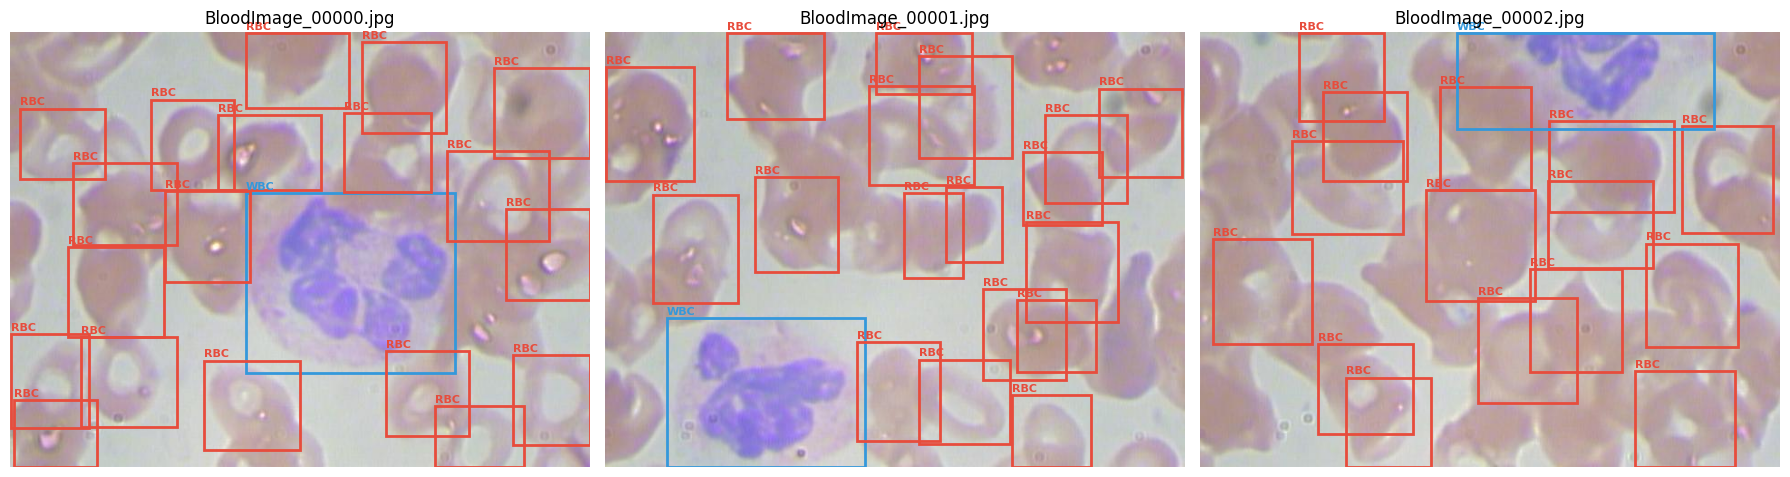

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

COLORS = {"RBC": "#e74c3c", "WBC": "#3498db", "Platelets": "#2ecc71"}


def show_sample(sample: Sample, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(np.array(Image.open(sample.image_path)))
    for box in sample.boxes:
        color = COLORS.get(box.label, "white")
        ax.add_patch(mpatches.Rectangle(
            (box.x1, box.y1), box.x2 - box.x1, box.y2 - box.y1,
            linewidth=2, edgecolor=color, facecolor="none",
        ))
        ax.text(box.x1, box.y1 - 4, box.label, color=color, fontsize=8, fontweight="bold")
    ax.axis("off")
    ax.set_title(sample.image_path.name)


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, s in zip(axes, samples[:3]):
    show_sample(s, ax)
plt.tight_layout()
plt.show()

### 2.3 Upload Images and Annotations to Datamint

In [6]:
uploaded = api.resources.upload_resources(
    [str(s.image_path) for s in samples],
    publish_to=proj,
    progress_bar=True,
)
print(f"Uploaded {len(uploaded)} images")

Uploading resources: 100%|██████████| 364/364 [02:51<00:00,  2.13file/s, file=BloodImage_00410.jpg]


Uploaded 364 images


In [ ]:
from tqdm.auto import tqdm

for sample, resource_id in tqdm(zip(samples, uploaded), total=len(samples), desc="Uploading annotations"):
    for box in sample.boxes:
        api.annotations.add_box_annotation(
            point1=(box.x1, box.y1),
            point2=(box.x2, box.y2),
            resource=resource_id,
            identifier=box.label,
        )
print("Annotations uploaded successfully!")

## 3. Training with YOLOXTrainer

This is where the **Trainer API** shines. Instead of manually defining:
- A detection dataset with the correct annotation parsing
- A variable-length collate function for bounding boxes
- A LightningModule wiring YOLOX's internal loss and NMS
- Callbacks, loggers, and a Lightning Trainer
- A deployment adapter

...you simply create a `YOLOXTrainer` and call `fit()`.

The trainer automatically:
1. Builds a `DetectionDataset` from the Datamint project
2. Constructs a stable class map from annotation identifiers, sorted alphabetically
3. Creates bbox-aware augmentation pipelines (resize, flip, color jitter, normalize)
4. Instantiates a `YOLOXModule` wrapping the chosen YOLOX variant
5. Configures MLflow logging, checkpointing on `val/map`, and early stopping
6. Trains, evaluates on the test split, and **registers the best checkpoint** in the MLflow Model Registry

| Index | Class |
|-------|-------|
| 0 | Platelets |
| 1 | RBC |
| 2 | WBC |

In [9]:
import random

all_resources = list(api.resources.get_list(project_name=PROJECT_NAME))
all_resources.sort(key=lambda r: r.filename)

random.seed(42)
random.shuffle(all_resources)

n_total = len(all_resources)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

train_resources = all_resources[:n_train]
val_resources = all_resources[n_train:n_train + n_val]
test_resources = all_resources[n_train + n_val:]

api.projects.assign_splits(proj, train_resources, split_name='train')
api.projects.assign_splits(proj, val_resources, split_name='val')
api.projects.assign_splits(proj, test_resources, split_name='test')

print(f"Train: {len(train_resources)}, Val: {len(val_resources)}, Test: {len(test_resources)}")

Train: 254, Val: 54, Test: 56


In [ ]:
from datamint.lightning import YOLOXTrainer

import os
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"

trainer = YOLOXTrainer(
    project=PROJECT_NAME,
    model_size="s",    # nano / tiny / s / m / l / x
    image_size=416,
    batch_size=8,
    max_epochs=100,
    early_stopping_patience=10,
    accelerator="auto",
)

results = trainer.fit()

In [7]:
# Class map built from annotations — needed to convert prediction indices back to names
class_map     = trainer.dataset._class_map            # {'Platelets': 0, 'RBC': 1, 'WBC': 2}
inv_class_map = {v: k for k, v in class_map.items()}  # {0: 'Platelets', 1: 'RBC', 2: 'WBC'}

print("Class map:   ", class_map)
print("Test metrics:", results["test_results"])

Class map:    {'Platelets': 0, 'RBC': 1, 'WBC': 2}
Test metrics: [{'test/map': 0.49530142545700073}]


## 4. Visualize Predictions

Let's visualize the model predictions against ground truth on test samples.

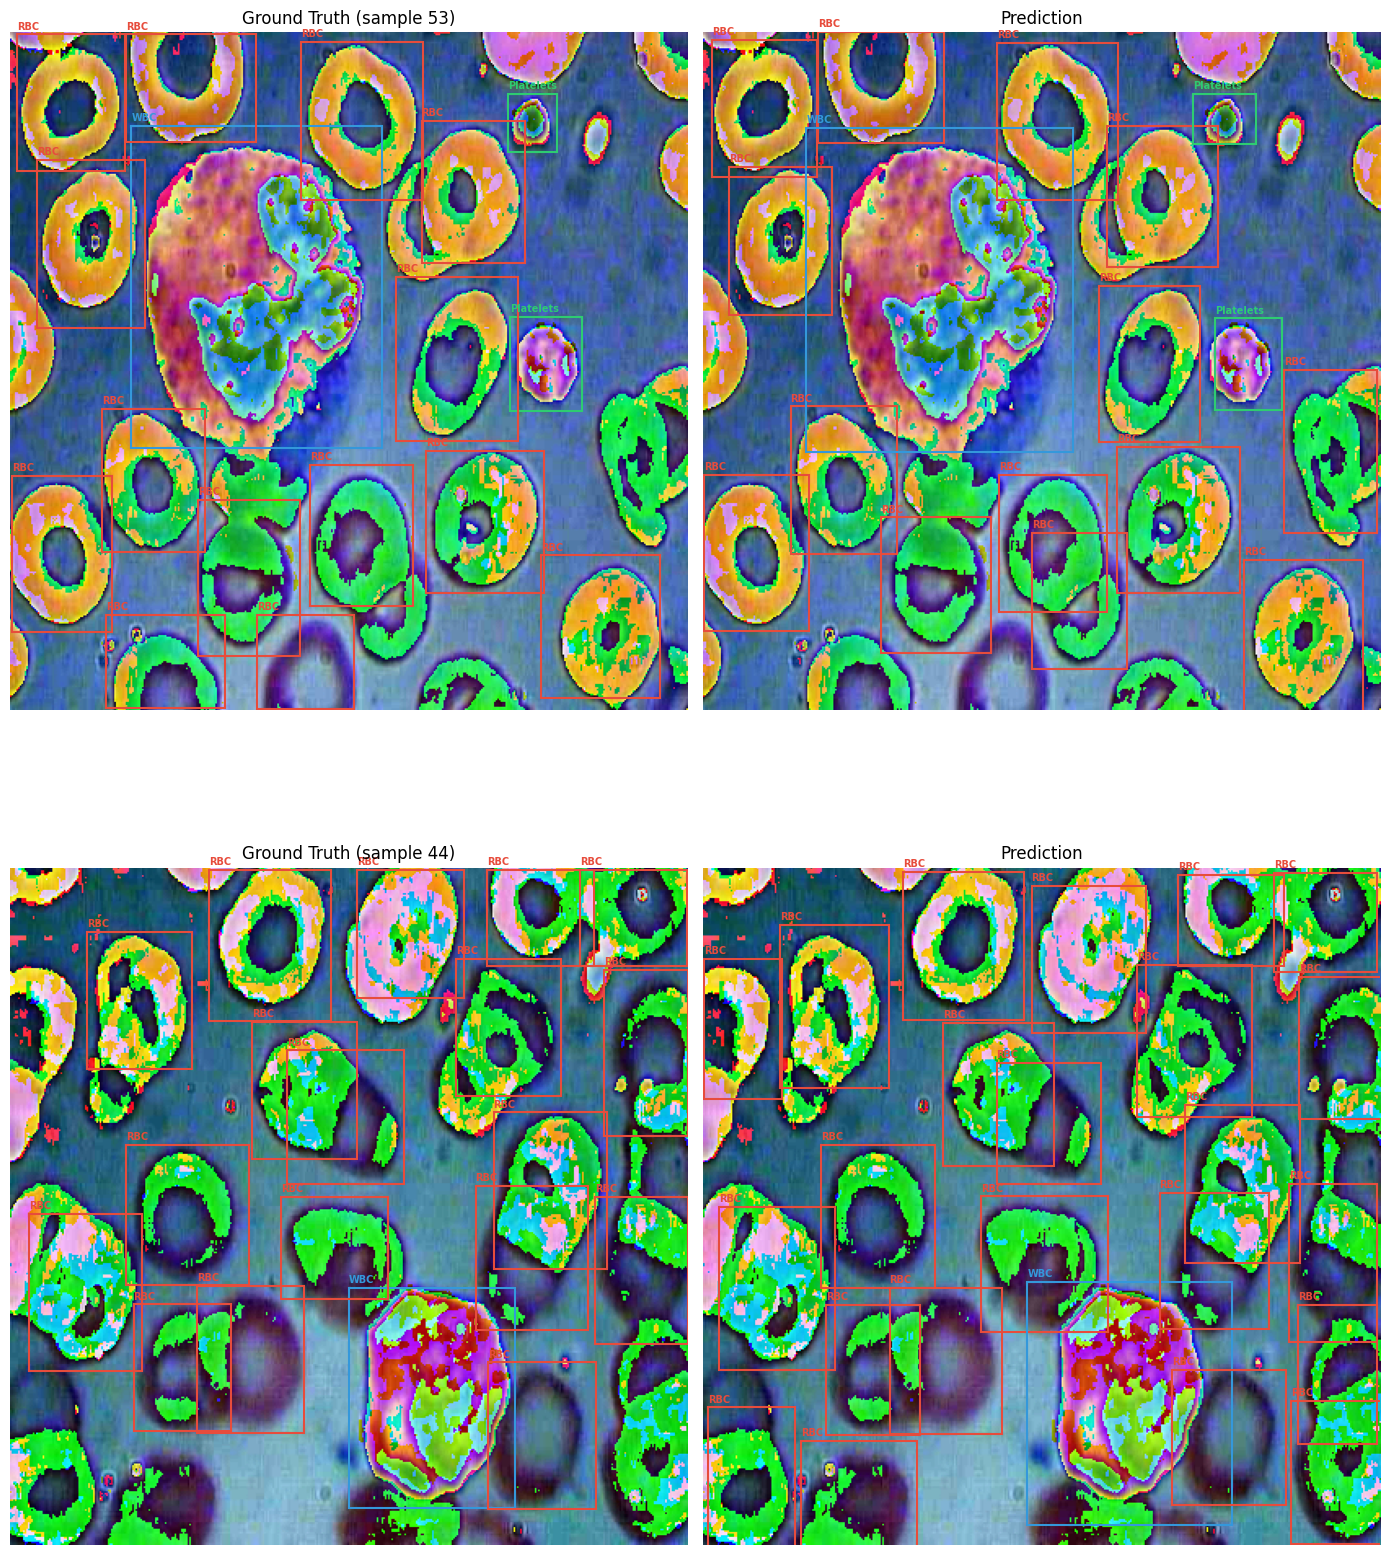

In [14]:
import torch
from yolox.utils import postprocess
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

COLORS = {"RBC": "#e74c3c", "WBC": "#3498db", "Platelets": "#2ecc71"}

model = trainer.model
model.eval()

test_dataset = trainer.datamodule.test_dataloader().dataset

fig, axes = plt.subplots(2, 2, figsize=(14, 18))

for row in range(2):
    idx = np.random.randint(len(test_dataset))
    sample = test_dataset[idx]
    image  = sample["image"]   # (C, H, W) tensor
    gt_boxes  = sample["boxes"]   # (N, 4) pascal_voc
    gt_labels = sample["labels"]  # (N,)

    with torch.inference_mode():
        raw  = model.model(image.unsqueeze(0).to(model.device))
        preds = postprocess(raw, model.hparams["num_classes"],
                            model.hparams["conf_thre"], model.hparams["nms_thre"])

    img_np = (image.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

    # Ground truth
    ax = axes[row, 0]
    ax.imshow(img_np)
    for box, lbl in zip(gt_boxes, gt_labels):
        cls_name = inv_class_map.get(int(lbl), str(int(lbl)))
        color = COLORS.get(cls_name, "white")
        x1, y1, x2, y2 = box.tolist()
        ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                         linewidth=1.5, edgecolor=color, facecolor="none"))
        ax.text(x1, y1 - 3, cls_name, color=color, fontsize=7, fontweight="bold")
    ax.set_title(f"Ground Truth (sample {idx})")
    ax.axis("off")

    # Prediction
    ax = axes[row, 1]
    ax.imshow(img_np)
    if preds[0] is not None:
        for det in preds[0].cpu():
            x1, y1, x2, y2 = det[:4].tolist()
            cls_name = inv_class_map.get(int(det[6]), str(int(det[6])))
            color = COLORS.get(cls_name, "white")
            ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                             linewidth=1.5, edgecolor=color, facecolor="none"))
            ax.text(x1, y1 - 3, cls_name, color=color, fontsize=7, fontweight="bold")
    ax.set_title("Prediction")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Deployment

The trainer **automatically** registered a deployment-ready model in MLflow after training.
You can deploy it directly to the Datamint server:

In [15]:
job = api.deploy.start(
    model_name=PROJECT_NAME,
    model_alias="latest",
    with_gpu=False,
)

print(f"Deployment job started!")
print(f"Job ID: {job.id}")
print(f"Status: {job.status}")

Deployment job started!
Job ID: 3c452320-cc89-4f4c-98d5-cd3c4b7ee6b8
Status: running


In [16]:
job = api.deploy.get_by_id(job.id)

print(f"Job Status: {job.status}")
print(f"Progress:   {job.progress_percentage}%")

if job.error_message:
    print(f"Error: {job.error_message}")

Job Status: running
Progress:   50%


### 5.1 Remote Inference

In [ ]:
r = api.resources.get_list(project_name=PROJECT_NAME, limit=1)[0]

inf_job = api.inference.submit(
    model_name=PROJECT_NAME,
    model_alias="latest",
    resource_id=r.id,
)
inf_job.wait()

In [ ]:
preds = inf_job.predictions[0]  # list[BoxAnnotation] for the first resource

img_np = np.array(r.fetch_file_data(auto_convert=True, use_cache=True))

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(img_np)
for box in preds:
    cls_name = inv_class_map.get(int(box.identifier), box.identifier)
    x1, y1, _ = box.geometry.point1
    x2, y2, _ = box.geometry.point2
    color = COLORS.get(cls_name, "white")
    ax.add_patch(mpatches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor=color, facecolor="none",
    ))
    ax.text(x1, y1 - 4, cls_name, color=color, fontsize=8, fontweight="bold")
ax.axis("off")
ax.set_title(getattr(r, "name", str(r.id)))
plt.tight_layout()
plt.show()

In [ ]:
proj.show()

## Summary: What the Trainer API Automates

The Trainer API automatically handles the full detection workflow, including:

- Dataset loading and box annotation parsing
- Variable-length collate function for bounding boxes
- Bbox-aware augmentation pipelines (resize, flip, color jitter, normalize)
- Stable class map construction from annotation identifiers
- YOLOX model instantiation (anchor-free, internal loss)
- Mean Average Precision metric configuration
- Lightning Trainer setup with early stopping on `val/map`
- MLflow experiment tracking and checkpoint registration
- Test-time evaluation
- Deployment-ready model artifact
